In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

datos = pd.DataFrame({
    'Estudiante': range(1, 11),
    'Horas': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Nota': [3.2, 4.5, 5.0, 6.8, 7.0, 8.5, 9.0, 9.2, 9.8, 10.0]
})
datos


,Estudiante,Horas,Nota
0,1,1,3.2
1,2,2,4.5
2,3,3,5.0
3,4,4,6.8
4,5,5,7.0
5,6,6,8.5
6,7,7,9.0
7,8,8,9.2
8,9,9,9.8
9,10,10,10.0


In [ ]:
x = datos['Horas'].values.astype(float)
y = datos['Nota'].values.astype(float)
n = len(x)
p = 1  # numero de variables predictoras

xbar, ybar = x.mean(), y.mean()

# Sxx y Sxy
Sxx = np.sum((x - xbar)**2)
Sxy = np.sum((x - xbar)*(y - ybar))

beta1_hat = Sxy / Sxx
beta0_hat = ybar - beta1_hat*xbar

print(f'xbar = {xbar:.4f}   ybar = {ybar:.4f}')
print(f'Sxx  = {Sxx:.4f}    Sxy  = {Sxy:.4f}')
print(f'beta0_hat = {beta0_hat:.6f}')
print(f'beta1_hat = {beta1_hat:.6f}')
print(f'\nModelo ajustado:  Y_hat = {beta0_hat:.4f} + {beta1_hat:.4f} * X')


xbar = 5.5000   ybar = 7.3000
Sxx  = 82.5000    Sxy  = 63.7000
beta0_hat = 3.053333
beta1_hat = 0.772121

Modelo ajustado:  Y_hat = 3.0533 + 0.7721 * X


In [ ]:
X = np.column_stack([np.ones(n), x])   # matriz de diseno [1, x]
beta_matricial = np.linalg.inv(X.T @ X) @ X.T @ y
print('beta (matricial) =', beta_matricial)

yhat = beta0_hat + beta1_hat*x
resid = y - yhat

tabla_residuos = pd.DataFrame({'Horas': x, 'Nota': y, 'yhat': yhat,
                                'residuo (e_i)': resid, 'e_i^2': resid**2})
tabla_residuos


beta (matricial) = [3.05333333 0.77212121]


,Horas,Nota,yhat,residuo (e_i),e_i^2
0,1.0,3.2,3.825455,-0.625455,0.391193
1,2.0,4.5,4.597576,-0.097576,0.009521
2,3.0,5.0,5.369697,-0.369697,0.136676
3,4.0,6.8,6.141818,0.658182,0.433203
4,5.0,7.0,6.913939,0.086061,0.007406
5,6.0,8.5,7.686061,0.813939,0.662497
6,7.0,9.0,8.458182,0.541818,0.293567
7,8.0,9.2,9.230303,-0.030303,0.000918
8,9.0,9.8,10.002424,-0.202424,0.040976
9,10.0,10.0,10.774545,-0.774545,0.599921


In [ ]:
SST = np.sum((y - ybar)**2)
SSR = np.sum((yhat - ybar)**2)
SSE = np.sum((y - yhat)**2)

df_reg = p
df_err = n - p - 1
df_tot = n - 1

MSR = SSR/df_reg
MSE = SSE/df_err
F_stat = MSR/MSE
p_valor_F = 1 - stats.f.cdf(F_stat, df_reg, df_err)

anova = pd.DataFrame({
    'Fuente': ['Regresion', 'Error', 'Total'],
    'SC (SS)': [SSR, SSE, SST],
    'gl': [df_reg, df_err, df_tot],
    'CM (MS)': [MSR, MSE, np.nan],
    'F': [F_stat, np.nan, np.nan],
    'p-valor': [p_valor_F, np.nan, np.nan]
})
anova


,Fuente,SC (SS),gl,CM (MS),F,p-valor
0,Regresion,49.184121,1,49.184121,152.752906,0.000002
1,Error,2.575879,8,0.321985,NaN,NaN
2,Total,51.760000,9,NaN,NaN,NaN


In [ ]:
R2 = SSR/SST
sigma2_hat = MSE                 # estimador insesgado de la varianza del error (slide 20)
sigma_hat = np.sqrt(sigma2_hat)

print(f'SST = {SST:.4f}   SSR = {SSR:.4f}   SSE = {SSE:.4f}   (SSR+SSE = {SSR+SSE:.4f})')
print(f'R^2 = {R2:.4f}  -> el modelo explica el {R2*100:.2f}% de la variabilidad de la Nota')
print(f'sigma2_hat (MSE) = {sigma2_hat:.4f}   sigma_hat = {sigma_hat:.4f}')


SST = 51.7600   SSR = 49.1841   SSE = 2.5759   (SSR+SSE = 51.7600)
R^2 = 0.9502  -> el modelo explica el 95.02% de la variabilidad de la Nota
sigma2_hat (MSE) = 0.3220   sigma_hat = 0.5674


In [ ]:
alpha = 0.05

se_beta1 = np.sqrt(MSE/Sxx)
se_beta0 = np.sqrt(MSE*(1/n + xbar**2/Sxx))

t_beta1 = beta1_hat/se_beta1
t_beta0 = beta0_hat/se_beta0

p_t_beta1 = 2*(1 - stats.t.cdf(abs(t_beta1), df_err))
p_t_beta0 = 2*(1 - stats.t.cdf(abs(t_beta0), df_err))

t_crit = stats.t.ppf(1 - alpha/2, df_err)
F_crit = stats.f.ppf(1 - alpha, df_reg, df_err)

tabla_pruebas = pd.DataFrame({
    'Parametro': ['beta0 (Intercepto)', 'beta1 (Pendiente)'],
    'Estimador': [beta0_hat, beta1_hat],
    'Error estandar': [se_beta0, se_beta1],
    't': [t_beta0, t_beta1],
    'p-valor': [p_t_beta0, p_t_beta1]
})
print(f'F calculada = {F_stat:.4f}   F_crit(alpha=0.05, 1,{df_err}) = {F_crit:.4f}   p-valor F = {p_valor_F:.3e}')
print(f't_crit(alpha=0.05, {df_err} gl) = {t_crit:.4f}\n')
tabla_pruebas


F calculada = 152.7529   F_crit(alpha=0.05, 1,8) = 5.3177   p-valor F = 1.712e-06
t_crit(alpha=0.05, 8 gl) = 2.3060



,Parametro,Estimador,Error estandar,t,p-valor
0,beta0 (Intercepto),3.053333,0.387633,7.876860,0.000049
1,beta1 (Pendiente),0.772121,0.062473,12.359325,0.000002


In [ ]:
conclusion_F = 'Se rechaza H0' if F_stat > F_crit else 'No se rechaza H0'
conclusion_t1 = 'Se rechaza H0' if abs(t_beta1) > t_crit else 'No se rechaza H0'
print(f'Prueba F -> {conclusion_F}: el modelo es globalmente significativo' if F_stat>F_crit else conclusion_F)
print(f'Prueba t (beta1) -> {conclusion_t1}: Horas de estudio SI influye en la Nota' if abs(t_beta1)>t_crit else conclusion_t1)


Prueba F -> Se rechaza H0: el modelo es globalmente significativo
Prueba t (beta1) -> Se rechaza H0: Horas de estudio SI influye en la Nota


In [ ]:
print(f't_beta1^2 = {t_beta1**2:.6f}')
print(f'F         = {F_stat:.6f}')
print(f'¿Coinciden? {np.isclose(t_beta1**2, F_stat)}')


t_beta1^2 = 152.752906
F         = 152.752906
¿Coinciden? True


In [ ]:
IC_beta1 = (beta1_hat - t_crit*se_beta1, beta1_hat + t_crit*se_beta1)
IC_beta0 = (beta0_hat - t_crit*se_beta0, beta0_hat + t_crit*se_beta0)

tabla_IC_coef = pd.DataFrame({
    'Parametro': ['beta0', 'beta1'],
    'Estimador': [beta0_hat, beta1_hat],
    'IC 95% inferior': [IC_beta0[0], IC_beta1[0]],
    'IC 95% superior': [IC_beta0[1], IC_beta1[1]]
})
tabla_IC_coef


,Parametro,Estimador,IC 95% inferior,IC 95% superior
0,beta0,3.053333,2.159449,3.947217
1,beta1,0.772121,0.628059,0.916184


In [ ]:
se_media = np.sqrt(MSE*(1/n + (x - xbar)**2/Sxx))
se_pred  = np.sqrt(MSE*(1 + 1/n + (x - xbar)**2/Sxx))

tabla_IC_IP = pd.DataFrame({
    'Horas (x0)': x,
    'Nota real': y,
    'y_hat': yhat,
    'IC media inf': yhat - t_crit*se_media,
    'IC media sup': yhat + t_crit*se_media,
    'IP inf': yhat - t_crit*se_pred,
    'IP sup': yhat + t_crit*se_pred
}).round(4)
tabla_IC_IP


,Horas (x0),Nota real,y_hat,IC media inf,IC media sup,IP inf,IP sup
0,1.0,3.2,3.8255,3.0564,4.5945,2.3077,5.3432
1,2.0,4.5,4.5976,3.9453,5.2498,3.1355,6.0597
2,3.0,5.0,5.3697,4.8211,5.9183,3.9508,6.7885
3,4.0,6.8,6.1418,5.6750,6.6086,4.7525,7.5311
4,5.0,7.0,6.9139,6.4939,7.3340,5.5397,8.2882
5,6.0,8.5,7.6861,7.2660,8.1061,6.3118,9.0603
6,7.0,9.0,8.4582,7.9914,8.9250,7.0689,9.8475
7,8.0,9.2,9.2303,8.6817,9.7789,7.8115,10.6492
8,9.0,9.8,10.0024,9.3502,10.6547,8.5403,11.4645
9,10.0,10.0,10.7745,10.0055,11.5436,9.2568,12.2923


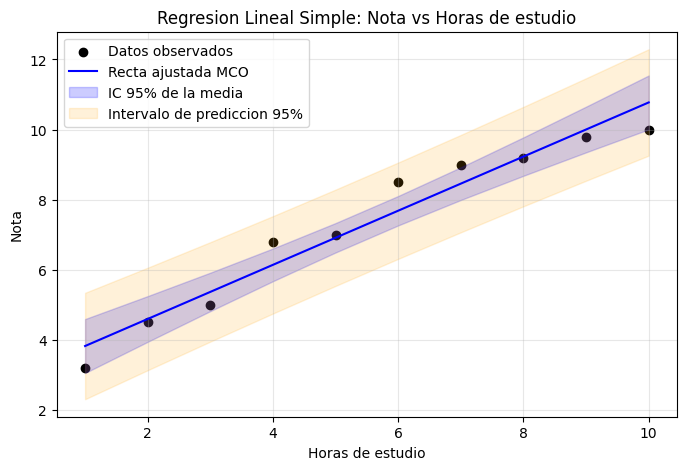

In [ ]:
orden = np.argsort(x)
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='black', label='Datos observados')
plt.plot(x[orden], yhat[orden], color='blue', label='Recta ajustada MCO')
plt.fill_between(x[orden], (yhat - t_crit*se_media)[orden], (yhat + t_crit*se_media)[orden],
                 color='blue', alpha=0.2, label='IC 95% de la media')
plt.fill_between(x[orden], (yhat - t_crit*se_pred)[orden], (yhat + t_crit*se_pred)[orden],
                 color='orange', alpha=0.15, label='Intervalo de prediccion 95%')
plt.xlabel('Horas de estudio')
plt.ylabel('Nota')
plt.title('Regresion Lineal Simple: Nota vs Horas de estudio')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
